# 03 – Testbare hypotheses: is er een patroon om te voorspellen?

| | |
|---|---|
| **Auteur(s)** | Kobe Vandenberk |
| **Wat** | Vóór we modellen bouwen: twee vooraf geformuleerde hypotheses statistisch toetsen, met effectgroottes. Ze moeten aantonen dat het weer en het dagritme de vraag echt (en sterk genoeg) bepalen om een voorspelmodel te rechtvaardigen. |
| **Input** | `data/station_hour.parquet`, `data/stations.parquet`, `data/weather_2024.parquet` |
| **Output** | `models/hypotheses.json` (resultaten) |
| **GenAI** | Code en tekst opgesteld met hulp van Claude; keuzes en resultaten nagekeken door Kobe. |

## De hypotheses (vastgelegd vóór het toetsen)
**H1 – Regen.** In uren met neerslag vertrekken er minder fietsen dan in droge uren, **bij hetzelfde uur, daltype (weekdag/weekend) en maand**.
- H₀: neerslag verandert het aantal vertrekken niet (verhouding nat/droog = 1).
- H₁: in natte uren vertrekken er minder fietsen (verhouding < 1). Eenzijdig.

**H2 – Dagritme.** De verdeling van de vertrekken over de uren van de dag is op weekdagen anders dan in het weekend (forenzenpieken vs. vrijetijdsfietsen).
- H₀: de uurverdeling is gelijk op weekdagen en in het weekend.
- H₁: de uurverdeling verschilt.

**Significantie-niveau:** α = 0,05.

## Waarom zo opgezet?
**Waarom vergelijken binnen hetzelfde uur en dezelfde maand (stratificeren)?** Regen valt niet willekeurig: in NYC regent het bv. vaker 's nachts of in bepaalde maanden. Vergelijk je zomaar alle natte met alle droge uren, dan meet je deels "nacht vs. dag" of "winter vs. zomer" in plaats van regen. Door alleen uren te vergelijken die verder gelijk zijn (zelfde uur, daltype, maand), isoleren we het effect van regen. Dat heet **confounding** wegwerken.

**Waarom effectgroottes?** Met miljoenen ritten wordt elk verschil "significant". De vraag is of het verschil groot genoeg is om ertoe te doen. Daarom rapporteren we naast p-waarden altijd hoe groot het effect is (en met een betrouwbaarheidsinterval).

## 0. Data: vertrekken in heel NYC per uur
Voor de hypotheses volstaat het stadstotaal per uur (publieke stations, zie 02 §5), met het weer erbij.

In [1]:
%matplotlib inline
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

import citibike as cb

station_hour = pd.read_parquet(cb.DATA_DIR / "station_hour.parquet")
stations = cb.clean_stations(pd.read_parquet(cb.DATA_DIR / "stations.parquet"))
weather = pd.read_parquet(cb.DATA_DIR / f"weather_{cb.YEAR}.parquet")

kept = set(stations.loc[stations["keep"], "start_station_id"])
hours = pd.date_range(f"{cb.YEAR}-01-01", f"{cb.YEAR}-12-31 23:00", freq="h")
city = (station_hour[station_hour["start_station_id"].isin(kept)].groupby("time")["trips"].sum()
        .reindex(hours, fill_value=0).rename_axis("time").reset_index().merge(weather, on="time"))
city["hour"] = city["time"].dt.hour
city["month"] = city["time"].dt.month
city["daytype"] = np.where(city["time"].dt.dayofweek >= 5, "weekend", "weekdag")
city.head()

,time,trips,temperature_c,precipitation_mm,wind_kmh,snowfall_cm,humidity_pct,hour,month,daytype
0,2024-01-01 00:00:00,1898,1.8,0.1,7.4,0.07,79,0,1,weekdag
1,2024-01-01 01:00:00,2329,1.3,0.0,8.7,0.00,81,1,1,weekdag
2,2024-01-01 02:00:00,1938,2.4,0.0,10.4,0.00,79,2,1,weekdag
3,2024-01-01 03:00:00,1098,2.7,0.0,9.2,0.00,79,3,1,weekdag
4,2024-01-01 04:00:00,655,2.7,0.0,7.9,0.00,79,4,1,weekdag


## H1 – Regen
### Definitie van "nat" en "droog"
- **droog**: 0 mm neerslag in dat uur;
- **nat**: ≥ 0,5 mm in dat uur (echte regen, geen motregen);
- uren daartussen (0–0,5 mm) laten we voor deze toets weg, zodat de twee groepen duidelijk verschillen. (Het model in 05 gebruikt wel de exacte hoeveelheid.)

Sneeuw telt als neerslag (Open-Meteo rekent smeltwater mee).

In [2]:
city["wet"] = np.select([city["precipitation_mm"] == 0, city["precipitation_mm"] >= 0.5], ["droog", "nat"], "tussen")
print(city["wet"].value_counts().to_string())

wet
droog     7504
tussen     715
nat        565


### Toets 1: gepaarde vergelijking per stratum (Wilcoxon signed-rank)
Per stratum (uur × daltype × maand) berekenen we het gemiddelde aantal vertrekken in natte en in droge uren. Strata waar er geen natte of geen droge uren zijn, vallen weg. Per stratum hebben we dan één **verhouding nat/droog**.

Als regen niets uitmaakt, liggen die verhoudingen rond 1 (log-verhouding rond 0): de helft erboven, de helft eronder. De **Wilcoxon signed-rank-toets** toetst of de mediaan van de log-verhoudingen kleiner is dan 0. Deze toets veronderstelt geen normale verdeling.

Strata met zowel natte als droge uren: 328
Mediaan verhouding nat/droog: 0.53  (95% van de strata heeft minder vertrekken bij regen)
Wilcoxon signed-rank (eenzijdig): W = 451, p = 4.84e-54


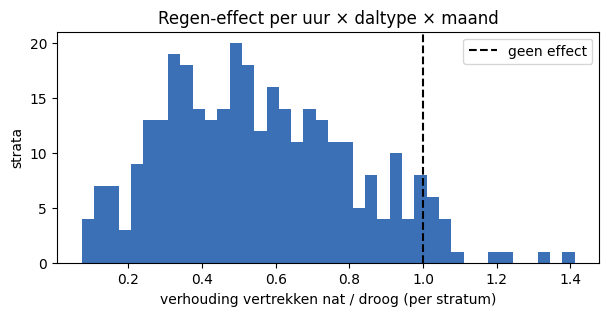

In [3]:
strata = (city[city["wet"] != "tussen"].groupby(["hour", "daytype", "month", "wet"])["trips"]
          .agg(["mean", "size"]).unstack("wet").dropna())
strata = strata[(strata[("mean", "droog")] > 0) & (strata[("mean", "nat")] > 0)]
log_ratio = np.log(strata[("mean", "nat")] / strata[("mean", "droog")])
wilcoxon = stats.wilcoxon(log_ratio, alternative="less")
print(f"Strata met zowel natte als droge uren: {len(log_ratio)}")
print(f"Mediaan verhouding nat/droog: {np.exp(log_ratio.median()):.2f}  "
      f"({(log_ratio < 0).mean():.0%} van de strata heeft minder vertrekken bij regen)")
print(f"Wilcoxon signed-rank (eenzijdig): W = {wilcoxon.statistic:.0f}, p = {wilcoxon.pvalue:.2e}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(np.exp(log_ratio), bins=40, color="#3b6fb6")
ax.axvline(1, color="black", ls="--", label="geen effect")
ax.set(xlabel="verhouding vertrekken nat / droog (per stratum)", ylabel="strata", title="Regen-effect per uur × daltype × maand")
ax.legend()
plt.show()

### Toets 2: Poisson-regressie met vaste effecten (hoe groot is het effect?)
De Wilcoxon-toets zegt *of* er een effect is. Om te weten *hoe groot*, schatten we één model op alle uren:

`log(verwacht aantal vertrekken) = effect(uur × daltype) + effect(dag) + β · nat`

(Technisch detail: het daltype zelf zit al in het dag-effect, want elke dag is een weekdag of een weekenddag. Daarom coderen we het uur apart binnen weekdagen en binnen weekenddagen, elk met 0u als referentie: `hour_weekday` en `hour_weekend`. Anders is het model niet eenduidig bepaald.)

- `effect(dag)`: één constante per kalenderdag (366 vaste effecten). Die vangt alles wat de hele dag geldt: seizoen, temperatuur van die dag, feestdagen, groei van het systeem. We vergelijken een nat uur dus met **droge uren van dezelfde dag**, op hetzelfde soort moment.
- `exp(β)` is de factor waarmee regen de vraag vermenigvuldigt.
- Tellingen zijn **overgedispergeerd** (variantie ≫ gemiddelde, zie 02 §10). Een gewone Poisson-regressie zou dan te kleine standaardfouten geven. We gebruiken daarom **robuuste (sandwich) standaardfouten**, geclusterd per dag, omdat uren van dezelfde dag samenhangen.

In [4]:
city["day"] = city["time"].dt.strftime("%m-%d")
city["hour_weekday"] = np.where(city["daytype"] == "weekdag", city["hour"], 0)
city["hour_weekend"] = np.where(city["daytype"] == "weekend", city["hour"], 0)
FIXED = "C(hour_weekday) + C(hour_weekend) + C(day)"

data = city[city["wet"] != "tussen"].assign(nat=lambda d: (d["wet"] == "nat").astype(int))
glm = smf.glm(f"trips ~ {FIXED} + nat", data=data, family=sm.families.Poisson()).fit(
    cov_type="cluster", cov_kwds={"groups": pd.factorize(data["day"])[0]})
beta, (lo, hi) = glm.params["nat"], glm.conf_int().loc["nat"]
p_one_sided = stats.norm.cdf(glm.tvalues["nat"])
print(f"Factor bij regen: {np.exp(beta):.3f}  -> {np.exp(beta) - 1:+.1%} vertrekken")
print(f"95%-BI: [{np.exp(lo) - 1:+.1%}, {np.exp(hi) - 1:+.1%}],  eenzijdige p = {p_one_sided:.2e}")

Factor bij regen: 0.731  -> -26.9% vertrekken
95%-BI: [-32.3%, -21.0%],  eenzijdige p = 9.15e-16


**Interpretatie H1:** H₀ wordt **verworpen**: regen verlaagt het aantal vertrekken duidelijk.
- **Per stratum** (328 combinaties van uur × daltype × maand met zowel natte als droge uren): in **95%** van de strata vertrekken er minder fietsen bij regen, met als mediaan maar **53%** van de droge vraag. Wilcoxon: p ≈ 5·10⁻⁵⁴.
- **Binnen dezelfde dag** (Poisson met dag-effecten): een nat uur heeft **27% minder** vertrekken dan een droog uur van dezelfde dag op hetzelfde soort moment (95%-BI: −32% tot −21%, p ≈ 10⁻¹⁵).

**Waarom zijn die twee getallen verschillend (−47% vs. −27%)?** Ze meten iets anders. De eerste vergelijkt natte uren met droge uren van *andere* dagen: daarin zit ook het effect van "het is een regendag" (wie 's ochtends regen ziet, laat de fiets de hele dag staan, ook in de droge uren). De tweede vergelijkt alleen binnen dezelfde dag en meet dus het effect van *dit uur* nat. Beide zijn nuttig: het model moet zowel het weer op het uur zelf kennen als het weer van de dag (via temperatuur en maand vangt het een deel daarvan).

### Dosis-effect: hoe meer regen, hoe minder fietsers?
Een echt oorzakelijk verband toont vaak een **dosis-effect**. We herhalen het model met neerslagklassen in plaats van nat/droog.

In [5]:
data_all = city.assign(rain_class=pd.cut(city["precipitation_mm"], [-0.01, 0, 0.5, 2, 5, 100],
                                         labels=["droog", "0-0.5", "0.5-2", "2-5", ">5"]))
dose = smf.glm(f"trips ~ {FIXED} + C(rain_class)", data=data_all, family=sm.families.Poisson()).fit(
    cov_type="cluster", cov_kwds={"groups": pd.factorize(data_all["day"])[0]})
effects = dose.params.filter(like="rain_class")          # namen zoals "C(rain_class)[T.0.5-2]"
ci = dose.conf_int().loc[effects.index]
labels = [name.split("[T.")[1][:-1] for name in effects.index]
dose_table = pd.DataFrame({"effect t.o.v. droog (%)": (np.exp(effects.to_numpy()) - 1) * 100,
                           "95%-BI laag (%)": (np.exp(ci[0].to_numpy()) - 1) * 100,
                           "95%-BI hoog (%)": (np.exp(ci[1].to_numpy()) - 1) * 100,
                           "aantal uren": data_all["rain_class"].value_counts()[labels].to_numpy()},
                          index=[f"{label} mm/u" for label in labels])
dose_table.round(1)

,effect t.o.v. droog (%),95%-BI laag (%),95%-BI hoog (%),aantal uren
0-0.5 mm/u,-11.1,-14.1,-8.0,773
0.5-2 mm/u,-25.1,-30.6,-19.2,336
2-5 mm/u,-34.2,-42.1,-25.3,129
>5 mm/u,-20.8,-31.0,-9.2,42


**Interpretatie:** tot 5 mm per uur is er een duidelijk **dosis-effect**: motregen (≤ 0,5 mm) kost 11%, matige regen 25%, stevige regen 34%. Boven 5 mm per uur is het effect kleiner (−21%), maar dat zijn maar 42 uren in het hele jaar met een breed betrouwbaarheidsinterval. Zulke uren zijn vaak korte zomerse onweersbuien: mensen wachten ze af en vertrekken nog binnen hetzelfde uur, of de bui viel niet op het punt waar het weermodel meet.

**Gevolg voor het model:** het effect is **niet lineair** in de hoeveelheid regen. Een boommodel kan dat zelf leren; in het lineaire model (05c) gebruiken we `log(1 + neerslag)`.

## H2 – Dagritme: weekdag vs. weekend
### Chi-kwadraattoets op de uurverdeling
We maken een kruistabel: rijen = daltype, kolommen = uur, cellen = totaal aantal vertrekken. De **chi-kwadraattoets op homogeniteit** toetst of de verdeling over de 24 uren gelijk is voor weekdagen en weekend.

Omdat het over miljoenen ritten gaat, zal de p-waarde praktisch 0 zijn. De **effectgrootte Cramér's V** (0 = geen verschil, 1 = volledig verschillend) zegt hoe groot het verschil echt is. Vuistregel bij 1 vrijheidsgraad in de kleinste dimensie: 0,1 klein, 0,3 middelmatig, 0,5 groot.

chi² = 1,783,818, vrijheidsgraden = 23, p = 0.00e+00, n = 44,269,890 vertrekken
Cramér's V = 0.201


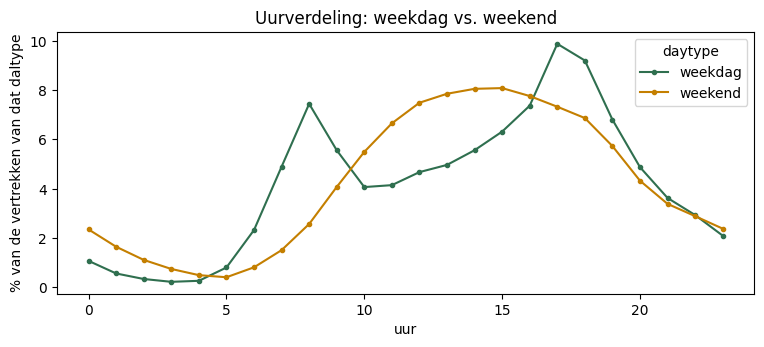

In [6]:
table = city.pivot_table(index="daytype", columns="hour", values="trips", aggfunc="sum")
chi2, p, dof, _ = stats.chi2_contingency(table)
n = table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
print(f"chi² = {chi2:,.0f}, vrijheidsgraden = {dof}, p = {p:.2e}, n = {n:,} vertrekken")
print(f"Cramér's V = {cramers_v:.3f}")

shares = table.div(table.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(9, 3.4))
shares.T.plot(ax=ax, color=["#2f6f4f", "#c47f00"], marker="o", ms=3)
ax.set(xlabel="uur", ylabel="% van de vertrekken van dat daltype", title="Uurverdeling: weekdag vs. weekend")
plt.show()

### Is het verschil stabiel? Permutatie per dag
De chi-kwadraattoets behandelt elke rit als onafhankelijk. Maar ritten op dezelfde dag hangen samen (weer, evenementen). Een strengere toets: we nemen de **dag** als eenheid. Per dag berekenen we het aandeel vertrekken in de ochtendspits (7–9u). Dan vergelijken we weekdagen en weekenddagen met een **Mann–Whitney U-toets** (dagen als onafhankelijke waarnemingen) en geven we het verschil in medianen met een bootstrap-interval.

In [7]:
per_day = city.assign(date=city["time"].dt.normalize(), morning=city["hour"].between(7, 9)) \
    .groupby(["date", "daytype"]).apply(lambda d: d.loc[d["morning"], "trips"].sum() / max(d["trips"].sum(), 1)) \
    .rename("aandeel_ochtendspits").reset_index()
wd = per_day.loc[per_day["daytype"] == "weekdag", "aandeel_ochtendspits"]
we = per_day.loc[per_day["daytype"] == "weekend", "aandeel_ochtendspits"]
mw = stats.mannwhitneyu(wd, we, alternative="two-sided")
rng = np.random.default_rng(cb.SEED)
boot = [np.median(rng.choice(wd, len(wd))) - np.median(rng.choice(we, len(we))) for _ in range(2000)]
print(f"Mediaan aandeel 7-9u: weekdag {wd.median():.1%}, weekend {we.median():.1%}")
print(f"Verschil: {wd.median() - we.median():+.1%} (95%-BI {np.percentile(boot, 2.5):+.1%} .. {np.percentile(boot, 97.5):+.1%})")
print(f"Mann-Whitney U = {mw.statistic:.0f}, p = {mw.pvalue:.2e}  ({len(wd)} weekdagen, {len(we)} weekenddagen)")

Mediaan aandeel 7-9u: weekdag 17.9%, weekend 8.3%
Verschil: +9.7% (95%-BI +9.2% .. +10.3%)
Mann-Whitney U = 26515, p = 2.83e-45  (262 weekdagen, 104 weekenddagen)


**Interpretatie H2:** H₀ wordt **verworpen**: de uurverdeling verschilt.
- De chi-kwadraattoets geeft p ≈ 0, maar met 44 miljoen ritten zegt dat weinig. De effectgrootte **Cramér's V = 0,20** is een klein tot middelmatig effect: een vijfde van de maximale afwijking, wat veel is als je bedenkt dat 's nachts beide daltypes even stil zijn.
- De grafiek toont *hoe* ze verschillen: op weekdagen twee spitsen (8u: 7,5%, 17u: 10% van de vertrekken), in het weekend één brede bult met de top rond 15u.
- Met de **dag als eenheid** (strenger): het aandeel van de ochtendspits (7–9u) is op weekdagen **17,9%** en in het weekend **8,3%**. Het verschil van 9,7 procentpunt heeft een smal betrouwbaarheidsinterval (9,2 tot 10,3) en de Mann–Whitney-toets geeft p ≈ 3·10⁻⁴⁵ op 262 weekdagen en 104 weekenddagen.

(Feestdagen tellen hier als weekdag; het model krijgt ze apart via `is_holiday`.)

## Hoeveel verklaren kalender en weer samen? (Opstap naar het model)
Een laatste controle vóór we modellen bouwen: verklaren deze factoren samen genoeg van de schommelingen om een voorspelmodel zinvol te maken? We vergelijken twee eenvoudige Poisson-modellen op het stadstotaal: alleen *uur × daltype + maand*, en daarnaast ook het weer.

In [8]:
city_m = city.assign(slot=city["hour"].astype(str) + "_" + city["daytype"], log_precip=np.log1p(city["precipitation_mm"]))
base = smf.glm("trips ~ C(slot) + C(month)", data=city_m, family=sm.families.Poisson()).fit()
full = smf.glm("trips ~ C(slot) + C(month) + bs(temperature_c, df=4) + log_precip + wind_kmh",
               data=city_m, family=sm.families.Poisson()).fit()
null_dev = base.null_deviance
explained = {"uur x daltype + maand": 1 - base.deviance / null_dev, "+ weer": 1 - full.deviance / null_dev}
print({k: f"{v:.1%} van de deviance verklaard" for k, v in explained.items()})

{'uur x daltype + maand': '89.1% van de deviance verklaard', '+ weer': '92.5% van de deviance verklaard'}


**Interpretatie:** op het niveau van de hele stad verklaart de kalender alleen (uur × daltype + maand) al **89%** van de deviance. Het weer voegt daar nog **3,4 procentpunt** aan toe (92,5%). De kalender bepaalt dus het grootste deel van het patroon, maar het weer maakt het verschil tussen een gewone en een "slechte" dag, precies de dagen waarop een planner het model nodig heeft. Per zone zal het moeilijker zijn: daar is er meer toeval, en elke zone heeft een eigen dagpatroon (02 §9).

In [9]:
results = {"H1_rain": {"wilcoxon_W": float(wilcoxon.statistic), "wilcoxon_p": float(wilcoxon.pvalue),
                       "strata": int(len(log_ratio)), "median_ratio_wet_dry": float(np.exp(log_ratio.median())),
                       "glm_factor": float(np.exp(beta)), "glm_ci95": [float(np.exp(lo)), float(np.exp(hi))],
                       "glm_p_one_sided": float(p_one_sided)},
           "H2_daily_rhythm": {"chi2": float(chi2), "dof": int(dof), "p": float(p), "cramers_v": float(cramers_v),
                               "morning_share_weekday": float(wd.median()), "morning_share_weekend": float(we.median()),
                               "mannwhitney_p": float(mw.pvalue)},
           "deviance_explained": {k: float(v) for k, v in explained.items()}}
cb.METRICS_DIR.mkdir(parents=True, exist_ok=True)
_ = (cb.MODEL_DIR / "hypotheses.json").write_text(json.dumps(results, indent=2))

## Conclusie
| Hypothese | Toets | Resultaat | Effectgrootte |
|---|---|---|---|
| H1: minder vertrekken bij regen | Wilcoxon per stratum; Poisson met dag-effecten | verworpen H₀ (p < 10⁻¹⁵) | −27% per nat uur (BI −32% tot −21%); dosis-effect tot 5 mm/u |
| H2: ander dagritme in het weekend | chi² + Mann–Whitney per dag | verworpen H₀ (p < 10⁻⁴⁴) | Cramér's V = 0,20; ochtendspits 17,9% vs. 8,3% |

Er is dus een **sterk, statistisch onderbouwd en praktisch relevant patroon** om te voorspellen. Dat bepaalt de kenmerken voor de modellen in 05: zone, uur, weekdag/weekend, maand, feestdag, temperatuur, neerslag (niet-lineair) en wind.